<a href="https://colab.research.google.com/github/jayasuneja/FWE458_Spring25/blob/main/Homework6_Suneja/Homework6_Suneja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6

In 2021, a paper was published in Nature entitled "A 10 percent increase in global land evapotranspiration (LE) from 2003 to 2019". But this paper was retracted by the authors later.

The main reason is that the authors mistakenly calculated the global mean evapotranspiration by missing the area weights.

## Step 1

Calculate the global (both area-weighted and not weighted) annual mean temperature in Celsius (TA) from 1990 to 2020 using the same air temperature data provided in the lecture notes (4pts)
* Use air.mon.mean.nc
* See Lectures 12 and 13 for this homework

In [3]:
# Downloading the dataset from NOAA

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import urllib.request
url = f"https://downloads.psl.noaa.gov/Datasets/ghcncams/air.mon.mean.nc"
air_mon_mean= url.split("/")[-1]
urllib.request.urlretrieve(url, air_mon_mean)

('air.mon.mean.nc', <http.client.HTTPMessage at 0x7f656abd4f10>)

In [4]:
# Opening the dataset
ds = xr.open_dataset(air_mon_mean)

# Extract air temperature DataArray
ta = ds["air"]
ta

ta = xr.open_dataarray(air_mon_mean)
ta

# ta.values, getting to know the dataset
data = ta.data
print(ta.dims)
print(ta.coords)
print(ta.attrs)
print(ta.shape)

('time', 'lat', 'lon')
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-02-01
{'long_name': 'Monthly mean of surface temperature', 'units': 'degK', 'dataset': 'NOAA/NCEP GHCN CAMS', 'var_desc': 'Air Temperature', 'level_desc': 'Surface', 'statistic': 'Mean', 'parent_stat': 'Other', 'standard_name': 'air_temperature', 'cell_methods': 'time: mean', 'valid_range': array([150., 400.], dtype=float32), 'actual_range': array([-49.21874, 335.75   ], dtype=float32)}
(926, 360, 720)


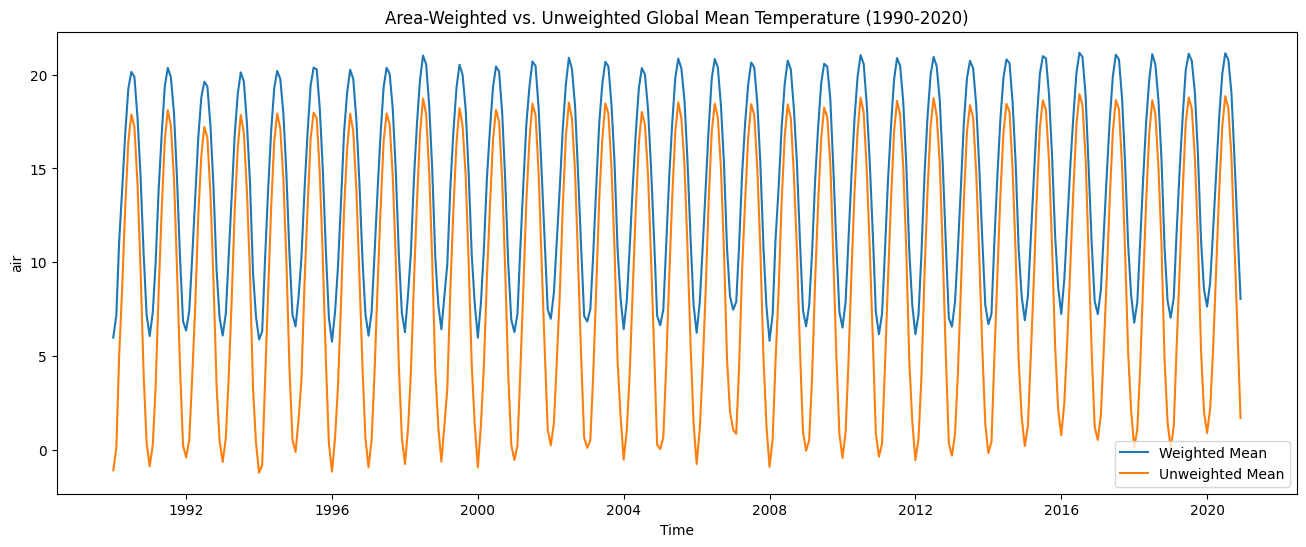

In [5]:
# Extracting the relevant data
air_temp = ds['air']
lat = ds['lat']
lon = ds['lon']
time = ds['time']

# It says the units are in K, so I have to convert to Celcius (C = K - 273.15)
air_temp_c = air_temp - 273.15

# Getting just 1990 to 2020 air temp data
air_temp_c = air_temp_c.sel(time = slice('1990-01-01', '2020-12-31'))

# Unweighted mean
unweighted_mean = air_temp_c.groupby('time.year').mean(dim=['lat', 'lon'])

# Weighted (by area)
weight = np.cos(np.deg2rad(lat))
air_weighted = air_temp_c.weighted(weight)
weighted_mean = air_weighted.mean(('lon', 'lat'))

# Plotting weighted vs unweighted
plt.figure(figsize = (16,6))
weighted_mean.plot(label = "Weighted Mean")
air_temp_c.mean(("lon", "lat")).plot(label= "Unweighted Mean")
plt.title("Area-Weighted vs. Unweighted Global Mean Temperature (1990-2020)")
plt.legend()

## Step 2

Visualize the time series of the global annual mean temperature (weighted and not weighted) from the first step with different colors/line styles
* x-axis = year
* y-axis = TA
* Ad trend lines with a fitted linear regression (TA = a*year + b) (3pts)


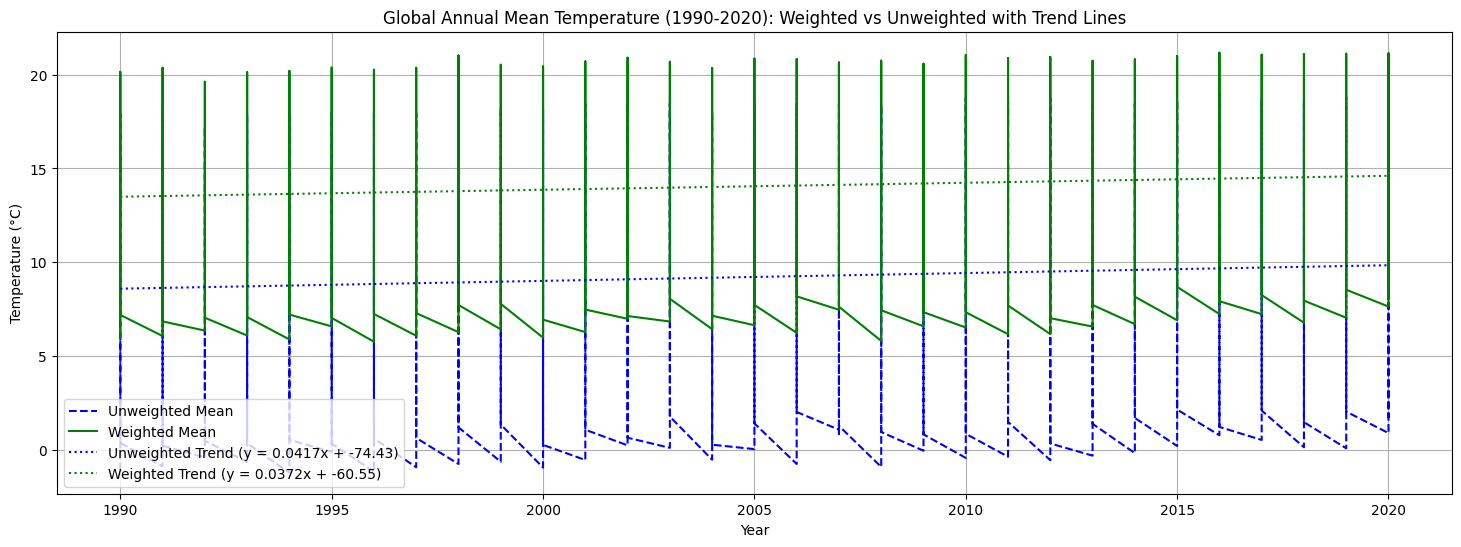

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Extracting years as integers
years = ds['time'].sel(time=slice('1990-01-01', '2020-12-31')).dt.year.values.astype(int)

# Convert means to numpy arrays
unweighted_values = unweighted_mean.values
weighted_values = weighted_mean.values

# Fitting the linear regression using numpy
coef_unweighted = np.polyfit(years, unweighted_values, 1)  # Linear fit
trend_unweighted = np.polyval(coef_unweighted, years)

coef_weighted = np.polyfit(years, weighted_values, 1)
trend_weighted = np.polyval(coef_weighted, years)

# Plotting the results
plt.figure(figsize=(18, 6))

# Original data
plt.plot(years, unweighted_values, label='Unweighted Mean', color='blue', linestyle='--')
plt.plot(years, weighted_values, label='Weighted Mean', color='green', linestyle='-')

# Trend lines
plt.plot(years, trend_unweighted, color='blue', linestyle=':',
         label=f'Unweighted Trend (y = {coef_unweighted[0]:.4f}x + {coef_unweighted[1]:.2f})')
plt.plot(years, trend_weighted, color='green', linestyle=':',
         label=f'Weighted Trend (y = {coef_weighted[0]:.4f}x + {coef_weighted[1]:.2f})')

# Labels and title
plt.title("Global Annual Mean Temperature (1990-2020): Weighted vs Unweighted with Trend Lines")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## Step 3

Visualize area-weighted and unweighted 31-year mean global air temperature map in robinson projection with colorbar in two panels in the same figure (3pts)

In [15]:
!pip install cartopy  --quiet

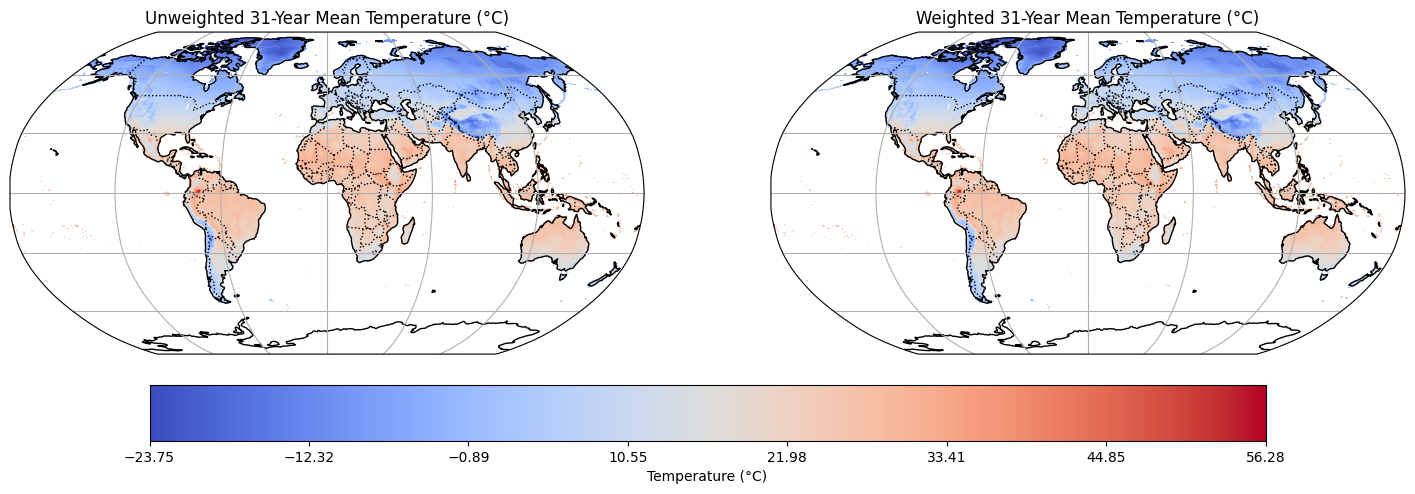

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Calculate the 31-year mean for both weighted and unweighted
mean_unweighted_map = air_temp_c.mean(dim='time')
weights = np.cos(np.deg2rad(air_temp_c['lat']))
weighted_mean_map = air_temp_c.weighted(weights).mean(dim='time')

# Create figure and axes
fig = plt.figure(figsize=(18, 8))
axs = [fig.add_subplot(1, 2, i+1, projection=ccrs.Robinson()) for i in range(2)]

# Plot unweighted mean map
p1 = axs[0].pcolormesh(mean_unweighted_map['lon'], mean_unweighted_map['lat'],
                       mean_unweighted_map, transform=ccrs.PlateCarree(), cmap='coolwarm')
axs[0].coastlines()
axs[0].set_title("Unweighted 31-Year Mean Temperature (°C)")
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].gridlines()

# Plot weighted mean map
p2 = axs[1].pcolormesh(weighted_mean_map['lon'], weighted_mean_map['lat'],
                       weighted_mean_map, transform=ccrs.PlateCarree(), cmap='coolwarm')
axs[1].coastlines()
axs[1].set_title("Weighted 31-Year Mean Temperature (°C)")
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].gridlines()

# Add colorbar at the bottom, spanning both plots
cbar = fig.colorbar(p2, ax=axs, orientation='horizontal', pad=0.05, shrink=0.8)

# Set colorbar label and ticks
cbar.set_label('Temperature (°C)')
cbar.set_ticks(np.linspace(weighted_mean_map.min(), weighted_mean_map.max(), 8))  # 8 ticks
cbar.ax.tick_params(labelsize=10)  # Adjust tick font size

plt.show()